In [1]:
%matplotlib widget

import numpy as np
import pandas as pd
import os
from blackjack.actions import PlayerAction, DealerAction
from blackjack.blackjack_round import BJRound, BJStage
from blackjack_cpp import ProbabilisticRankShoe, RandomSampler, load_combo_data
from blackjack.rules import BJRules
import time
import random
import tqdm
import pickle
from blackjack.ev_estimator import EVEstimator
from sklearn.linear_model import LinearRegression
from blackjack import treewalker_play
import logging
from datetime import datetime
import matplotlib.pyplot as plt

from strategy import CardCounter
from blackjack import count_strategy_play
from strategy import DeviatedBasicStrategy


In [2]:
# get current directory
current_dir = os.getcwd()
load_combo_data(os.path.join(current_dir, "../combinations/s16_new/"), 11)

In [3]:
rules = BJRules(
    dealer_checks_blackjack = True,
    dealer_hits_soft_17 = False,
    allow_late_surrender = False,
    allow_early_surrender_on_ten = False,
    allow_early_surrender_on_ace = False,
    allow_early_surrender_on_all = False,
    dealer_shows_card_on_surrender = True,
    allow_insurance_vs_ace = True,
    natural_blackjack_payout = 3 / 2,
    surrender_payout = 1 / 2,
    insurance_payout = 2 / 1,
    max_splits_allowed = 1,
    allow_action_on_split_aces = True,
    allow_double_after_split = True,
    allow_double_on_soft = True,
    allow_split_different_tens = True
)

In [4]:
int(-1.9)

-1

In [ ]:
sklearn_models_folder = "../sklearn_models"

synth_count_path = os.path.join(sklearn_models_folder, "synthetic_count_from_ev.pkl")
synthetic_count_from_ev = pickle.load(open(synth_count_path, "rb"))

ev_estimator: EVEstimator = pickle.load(open(os.path.join(sklearn_models_folder, "ev_estimator_cubic.pkl"), "rb"))

# Load HiLo deviation strategy EV model (proportions + counts, 20 features)
# hilo_ev_estimator = pickle.load(open(os.path.join(sklearn_models_folder, "hilo_ev_proportions_counts.pkl"), "rb"))
hilo_ev_estimator = pickle.load(open(os.path.join(sklearn_models_folder, "hilo_ev_proportions.pkl"), "rb"))
print(f"Loaded HiLo EV estimator: {hilo_ev_estimator}")

Loaded HiLo EV estimator: EVEstimator(degree=1, fitted, R²=0.0002)


In [6]:

log_filename = f"../logs/log_treewalker_strategy.txt"
# clear file
open(log_filename, 'w').close()

# Configure logger
logger = logging.getLogger("BJRoundTest")
logger.setLevel(logging.INFO)

file_handler = logging.FileHandler(log_filename)
file_handler.setLevel(logging.INFO)

if logger.handlers:
    logger.handlers.clear()

logger.addHandler(file_handler)

print(f"Logging to {log_filename}")


Logging to ../logs/log_treewalker_strategy.txt


In [7]:
def count_to_bet_scale(int_count):
    if int_count >= 6:
        return 20
    elif int_count >= 5:
        return 18
    elif int_count >= 4:
        return 14
    elif int_count >= 3:
        return 10
    elif int_count >= 2:
        return 6
    elif int_count >= 1:
        return 3
    else:
        return 1


In [8]:
n_shoes_sim = 300
values_by_shoe_tw = []
evs_by_shoe_tw = []
all_values_tw = []
all_evs_tw = []

random.seed(23)
seeds = [random.randrange(10000000) for _ in range(n_shoes_sim)]

for shoe_i in tqdm.tqdm(range(n_shoes_sim)):
    seed = random.randrange(10000000)
    shoe_tw = ProbabilisticRankShoe(n_decks=6, seed=seeds[shoe_i])

    small_bet = 1000

    evs_tw = []
    values_tw = []
    hand_i = 0
    while sum(shoe_tw.get_rank_count().values()) >= 52:
        ev_estimate = ev_estimator.predict(shoe_tw.get_rank_count())
        synth_count = synthetic_count_from_ev.predict(np.atleast_2d(ev_estimate))
        int_count = int(synth_count.item())

        # 6–8 deck shoe (standard ramp)
        # TC ≤ 0: 1u
        # TC +1: 2u
        # TC +2: 4u
        # TC +3: 7u
        # TC +4: 10u
        # TC +5: 14u
        # TC +6: 17u
        # TC ≥ +7: 20u

        # 6–8 deck shoe (aggressive)
        # TC ≤ 0: 1u
        # TC +1: 3u
        # TC +2: 6u
        # TC +3: 10u
        # TC +4: 14u
        # TC +5: 18u
        # TC ≥ +6: 20u

        # 5-5-5-4-2 this is a correct on-ramp for 1-5 spread
        
        tw_bet = small_bet * count_to_bet_scale(int_count)

        end_round_tw = treewalker_play.play_round(
            rules,
            shoe_tw,
            tw_bet,
            logger
        )
        
        values_tw.append(end_round_tw.get_player_value())
        all_values_tw.append(end_round_tw.get_player_value())
        evs_tw.append(ev_estimate)
        all_evs_tw.append(ev_estimate / 100 * tw_bet)
        hand_i += 1

    values_by_shoe_tw.append(values_tw)
    evs_by_shoe_tw.append(evs_tw)

100%|██████████| 300/300 [01:57<00:00,  2.55it/s]


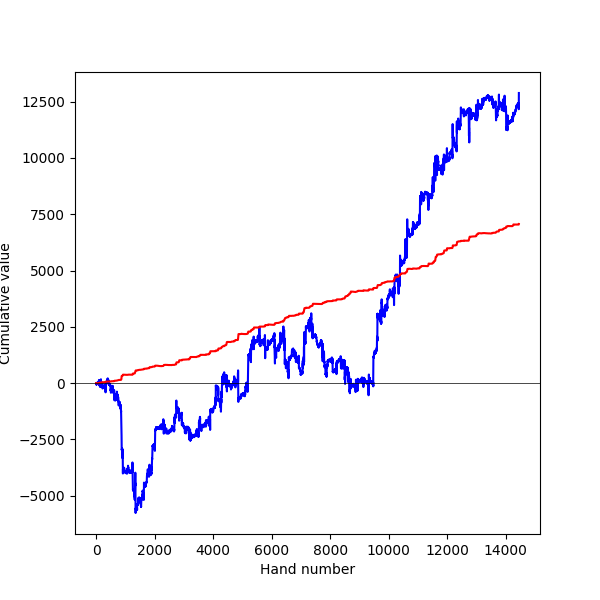

In [9]:
f, ax = plt.subplots(figsize=(6, 6))

cum_values_tw = np.cumsum(all_values_tw)
cum_values_tw = np.r_[[0], cum_values_tw]
cum_values_tw = cum_values_tw / 100


cum_evs_tw = np.cumsum(all_evs_tw)
cum_evs_tw = np.r_[[0], cum_evs_tw]
cum_evs_tw = cum_evs_tw / 100

ax.plot(cum_values_tw, color="blue")
ax.plot(cum_evs_tw, color="red")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Hand number")
ax.set_ylabel("Cumulative value")
plt.show()

In [10]:

dev_strategy = DeviatedBasicStrategy(
    basic_strategy_folder="../strategy",
    deviation_strategy_folder="../strategy"
)


values_by_shoe_dev = []
tc_by_shoe_dev = []
all_values_dev = []
all_evs_dev = []
true_count_dev = []

for shoe_i in tqdm.tqdm(range(n_shoes_sim)):
    shoe_dev = ProbabilisticRankShoe(n_decks=6, seed=seeds[shoe_i])
    counter_dev = CardCounter(n_decks=6)

    small_bet = 1000

    values_dev = []
    tc_values_dev = []
    hand_i = 0
    while (
        sum(shoe_dev.get_rank_count().values()) >= 52
    ):
        tc_int_dev = counter_dev.get_integer_tc()
        tc_dev = counter_dev.get_true_count()
        
        # if hand_i >= 2 and tc_dev < 0.5:
        #     break
        # if hand_i >= 4 and tc_dev < 1:
        #     break 

        dev_bet = small_bet
        # • Enter at +1: 3u
        # • TC ≤ 0: 1u
        # • +1: 2u
        # • +2: 4u
        # • +3: 6u
        # • +4: 8u
        # • ≥+5: 10u
        
        # if tc_int_dev >= 5:
        #     dev_bet = small_bet * 10
        # elif tc_int_dev >= 4:
        #     dev_bet = small_bet * 8
        # elif tc_int_dev >= 3:
        #     dev_bet = small_bet * 6
        # elif tc_int_dev >= 2:
        #     dev_bet = small_bet * 4
        # elif tc_int_dev >= 1:
        #     dev_bet = small_bet * 2
        # else:
        #     dev_bet = small_bet

        # 6–8 deck shoe (standard ramp)
        # TC ≤ 0: 1u
        # TC +1: 2u
        # TC +2: 4u
        # TC +3: 7u
        # TC +4: 10u
        # TC +5: 14u
        # TC +6: 17u
        # TC ≥ +7: 20u

        # 6–8 deck shoe (aggressive)
        # TC ≤ 0: 1u
        # TC +1: 3u
        # TC +2: 6u
        # TC +3: 10u
        # TC +4: 14u
        # TC +5: 18u
        # TC ≥ +6: 20u

        # 5-5-5-4-2 this is a correct on-ramp for 1-5 spread

        dev_bet = small_bet * count_to_bet_scale(tc_int_dev)
        
        # HiLo EV prediction
        hilo_ev_estimate = hilo_ev_estimator.predict(shoe_dev.get_rank_count())

        end_round_dev = count_strategy_play.play_round(
            rules,
            shoe_dev, dev_bet, counter_dev, dev_strategy
        )

        values_dev.append(end_round_dev.get_player_value())
        all_values_dev.append(end_round_dev.get_player_value())
        all_evs_dev.append(hilo_ev_estimate / 100 * dev_bet)
        true_count_dev.append(tc_dev)
        tc_values_dev.append(tc_dev)
        hand_i += 1

    tc_values_dev.append(tc_values_dev)
    values_by_shoe_dev.append(values_dev)
    

100%|██████████| 300/300 [00:03<00:00, 79.73it/s]


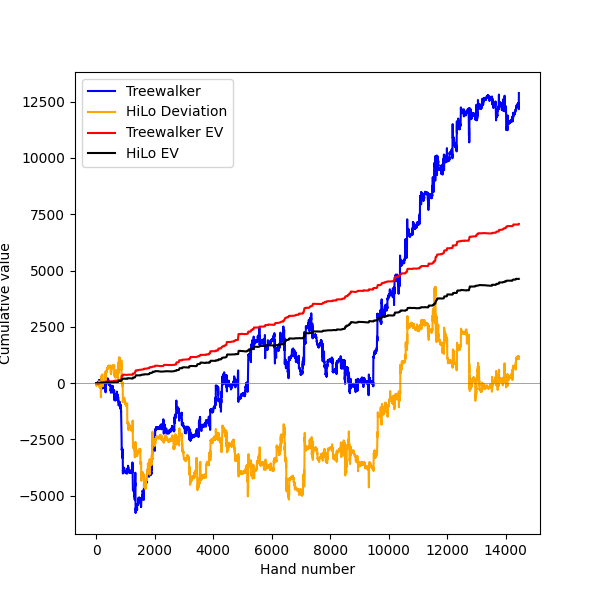

In [11]:
f, ax = plt.subplots(figsize=(6, 6))

cum_values_dev = np.cumsum(all_values_dev)
cum_values_dev = np.r_[[0], cum_values_dev]
cum_values_dev = cum_values_dev / 100

cum_evs_dev = np.cumsum(all_evs_dev)
cum_evs_dev = np.r_[[0], cum_evs_dev]
cum_evs_dev = cum_evs_dev / 100

ax.plot(cum_values_tw, color="blue", label="Treewalker")
ax.plot(cum_values_dev, color="orange", label="HiLo Deviation")
ax.plot(cum_evs_tw, color="red", label="Treewalker EV")
ax.plot(cum_evs_dev, color="black", label="HiLo EV")

ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Hand number")
ax.set_ylabel("Cumulative value")
ax.legend()

plt.show()

In [12]:
# Pad shorter lists with zeros to match the longest in each pair
padded_values_dev = []
padded_values_tw = []

for values_dev, values_tw in zip(values_by_shoe_dev, values_by_shoe_tw):
    max_len = max(len(values_dev), len(values_tw))
    
    # Pad with zeros
    padded_dev = values_dev + [0] * (max_len - len(values_dev))
    padded_tw = values_tw + [0] * (max_len - len(values_tw))
    
    padded_values_dev.extend(padded_dev)
    padded_values_tw.extend(padded_tw)


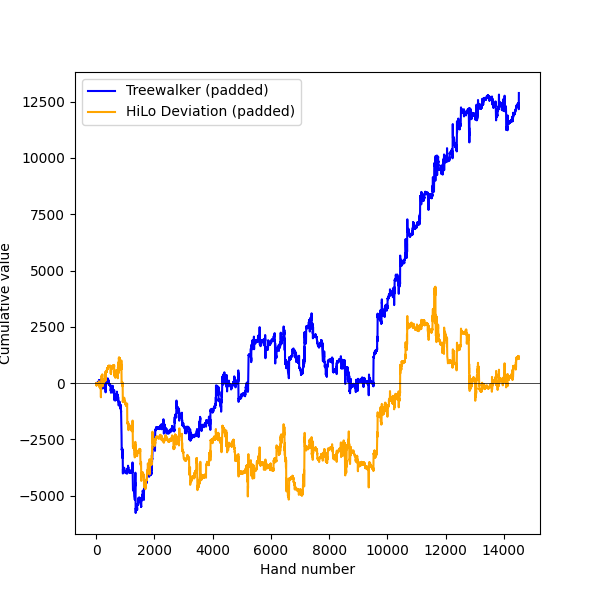

In [13]:
f, ax = plt.subplots(figsize=(6, 6))

cum_padded_dev = np.cumsum(padded_values_dev)
cum_padded_dev = np.r_[[0], cum_padded_dev]
cum_padded_dev = cum_padded_dev / 100

cum_padded_tw = np.cumsum(padded_values_tw)
cum_padded_tw = np.r_[[0], cum_padded_tw]
cum_padded_tw = cum_padded_tw / 100

ax.plot(cum_padded_tw, color="blue", label="Treewalker (padded)")
ax.plot(cum_padded_dev, color="orange", label="HiLo Deviation (padded)")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Hand number")
ax.set_ylabel("Cumulative value")
ax.legend()

plt.show()


In [14]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing

dev_strategy = DeviatedBasicStrategy(
    basic_strategy_folder="../strategy",
    deviation_strategy_folder="../strategy"
)


def simulate_both_strategies(seed):
    """
    Simulate both treewalker and HiLo deviation strategies on the same shoe.
    Both players see the same cards at the start of each round.
    """
    # Build the common reference shoe
    reference_shoe = ProbabilisticRankShoe(n_decks=6, seed=seed)
    counter_dev = CardCounter(n_decks=6)
    small_bet = 1000
    
    values_tw = []
    evs_tw = []
    values_dev = []
    evs_dev = []  # HiLo EV predictions
    tc_values_dev = []
    
    while len(reference_shoe) >= 52:
        # Copy the reference shoe to both players
        shoe_tw = reference_shoe.copy()
        shoe_dev = reference_shoe.copy()
        
        # Treewalker bet calculation
        ev_estimate = ev_estimator.predict(shoe_tw.get_rank_count())
        synth_count = synthetic_count_from_ev.predict(np.atleast_2d(ev_estimate))
        int_count_tw = int(synth_count.item())
        tw_bet = small_bet * count_to_bet_scale(int_count_tw)
        
        # HiLo Deviation bet calculation
        tc_int_dev = counter_dev.get_integer_tc()
        tc_dev = counter_dev.get_true_count()
        dev_bet = small_bet * count_to_bet_scale(tc_int_dev)
        
        # HiLo EV prediction (uses raw counts as input)
        rank_count = shoe_dev.get_rank_count()
        hilo_ev_estimate = hilo_ev_estimator.predict(rank_count)
        
        # Play both rounds
        end_round_tw = treewalker_play.play_round(rules, shoe_tw, tw_bet, logger)
        end_round_dev = count_strategy_play.play_round(
            rules, shoe_dev, dev_bet, counter_dev, dev_strategy
        )
        
        # Record results
        values_tw.append(end_round_tw.get_player_value())
        evs_tw.append(ev_estimate / 100 * tw_bet)
        values_dev.append(end_round_dev.get_player_value())
        evs_dev.append(hilo_ev_estimate / 100 * dev_bet)  # Scale by bet
        tc_values_dev.append(tc_dev)
        
        # Get sizes of both shoe copies after play
        size_tw = len(shoe_tw)
        size_dev = len(shoe_dev)
        
        # Copy the smallest shoe to be the new reference
        if size_tw <= size_dev:
            reference_shoe = shoe_tw
        else:
            reference_shoe = shoe_dev
    
    return values_tw, evs_tw, values_dev, evs_dev, tc_values_dev


In [24]:
# Parallel simulation parameters
n_shoes_parallel = 50000
n_workers = multiprocessing.cpu_count()

seed = int(time.time()) % 1234567890
print(f"Seed: {seed}")
random.seed(seed)
seeds_parallel = [random.randrange(10000000) for _ in range(n_shoes_parallel)]

print(f"Running combined parallel simulation with {n_workers} workers for {n_shoes_parallel} shoes")


Seed: 531546885
Running combined parallel simulation with 16 workers for 50000 shoes


In [25]:
# Run combined simulation in parallel
print("Running combined simulation (both strategies on same shoe)...")

values_by_shoe_tw_parallel = []
evs_by_shoe_tw_parallel = []
all_values_tw_parallel = []
all_evs_tw_parallel = []

values_by_shoe_dev_parallel = []
evs_by_shoe_dev_parallel = []
tc_by_shoe_dev_parallel = []
all_values_dev_parallel = []
all_evs_dev_parallel = []
all_tc_dev_parallel = []

print("\n" * 3)
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    results = list(tqdm.tqdm(executor.map(simulate_both_strategies, seeds_parallel), total=n_shoes_parallel))

for values_tw, evs_tw, values_dev, evs_dev, tc_values_dev in results:
    values_by_shoe_tw_parallel.append(values_tw)
    evs_by_shoe_tw_parallel.append(evs_tw)
    all_values_tw_parallel.extend(values_tw)
    all_evs_tw_parallel.extend(evs_tw)
    
    values_by_shoe_dev_parallel.append(values_dev)
    evs_by_shoe_dev_parallel.append(evs_dev)
    tc_by_shoe_dev_parallel.append(tc_values_dev)
    all_values_dev_parallel.extend(values_dev)
    all_evs_dev_parallel.extend(evs_dev)
    all_tc_dev_parallel.extend(tc_values_dev)

print(f"Treewalker: {len(all_values_tw_parallel)} hands simulated")
print(f"HiLo Deviation: {len(all_values_dev_parallel)} hands simulated")


Running combined simulation (both strategies on same shoe)...






100%|██████████| 50000/50000 [1:11:46<00:00, 11.61it/s]


Treewalker: 2394284 hands simulated
HiLo Deviation: 2394284 hands simulated


In [26]:
# Check if padding is needed (should not happen with combined simulation)
padded_values_dev_parallel = []
padded_values_tw_parallel = []
padding_needed = 0

for values_dev, values_tw in zip(values_by_shoe_dev_parallel, values_by_shoe_tw_parallel):
    if len(values_dev) != len(values_tw):
        padding_needed += 1
    
    max_len = max(len(values_dev), len(values_tw))
    
    padded_dev = values_dev + [0] * (max_len - len(values_dev))
    padded_tw = values_tw + [0] * (max_len - len(values_tw))
    
    padded_values_dev_parallel.extend(padded_dev)
    padded_values_tw_parallel.extend(padded_tw)

if padding_needed > 0:
    print(f"WARNING: Padding was needed for {padding_needed} shoes! This should not happen.")


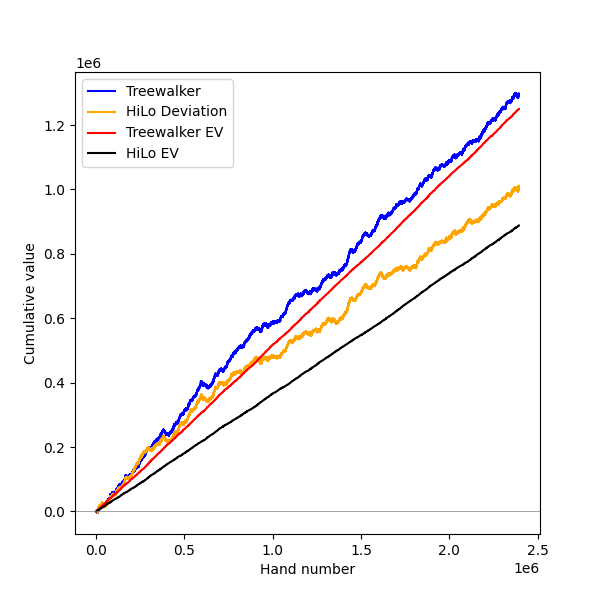

In [27]:
# Plot parallel results
f, ax = plt.subplots(figsize=(6, 6))

cum_padded_dev_parallel = np.cumsum(padded_values_dev_parallel)
cum_padded_dev_parallel = np.r_[[0], cum_padded_dev_parallel]
cum_padded_dev_parallel = cum_padded_dev_parallel / 100

cum_padded_tw_parallel = np.cumsum(padded_values_tw_parallel)
cum_padded_tw_parallel = np.r_[[0], cum_padded_tw_parallel]
cum_padded_tw_parallel = cum_padded_tw_parallel / 100

cum_evs_tw_parallel = np.cumsum(all_evs_tw_parallel)
cum_evs_tw_parallel = np.r_[[0], cum_evs_tw_parallel]
cum_evs_tw_parallel = cum_evs_tw_parallel / 100

cum_evs_dev_parallel = np.cumsum(all_evs_dev_parallel)
cum_evs_dev_parallel = np.r_[[0], cum_evs_dev_parallel]
cum_evs_dev_parallel = cum_evs_dev_parallel / 100

ax.plot(cum_padded_tw_parallel, color="blue", label="Treewalker")
ax.plot(cum_padded_dev_parallel, color="orange", label="HiLo Deviation")
ax.plot(cum_evs_tw_parallel, color="red", label="Treewalker EV")
ax.plot(cum_evs_dev_parallel, color="black", label="HiLo EV")

ax.axhline(0, color="grey", linewidth=0.5)
ax.set_xlabel("Hand number")
ax.set_ylabel("Cumulative value")
ax.legend()

plt.show()


In [28]:
cum_padded_tw_parallel[-1] / cum_padded_dev_parallel[-1]

np.float64(1.2831843964967287)

In [29]:
cum_evs_tw_parallel[-1] / cum_evs_dev_parallel[-1]

np.float64(1.407496717668539)